In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import spearmanr, mannwhitneyu
import statsmodels.api as sm

In [2]:
products = pd.read_csv("product_info.csv")
ethics = pd.read_csv("cf_products_with_retailers.csv")

In [3]:
print("Products dataset shape:", products.shape)
print("Ethics dataset shape:", ethics.shape)

print("\nProducts columns:")
print(products.columns.tolist())

print("\nEthics columns:")
print(ethics.columns.tolist())

Products dataset shape: (8494, 27)
Ethics dataset shape: (922, 11)

Products columns:
['product_id', 'product_name', 'brand_id', 'brand_name', 'loves_count', 'rating', 'reviews', 'size', 'variation_type', 'variation_value', 'variation_desc', 'ingredients', 'price_usd', 'value_price_usd', 'sale_price_usd', 'limited_edition', 'new', 'online_only', 'out_of_stock', 'sephora_exclusive', 'highlights', 'primary_category', 'secondary_category', 'tertiary_category', 'child_count', 'child_max_price', 'child_min_price']

Ethics columns:
['Unnamed: 0', 'Brand', 'All_vegan', 'Partial_vegan', 'Bad_parent_company', 'Black_owned', 'Ulta', 'Sephora', 'Beauty_Bay', 'Cult_Beauty', 'Nordstrom']


In [4]:
skincare = products[products["primary_category"] == "Skincare"].copy()

print("Total skincare products before cleaning:", len(skincare))
print("Unique skincare brands before cleaning:", skincare["brand_name"].nunique())

Total skincare products before cleaning: 2420
Unique skincare brands before cleaning: 143


In [5]:
skincare = skincare[
    [
        "brand_name",
        "product_name",
        "rating",
        "reviews",
        "price_usd",
        "primary_category",
        "secondary_category",
        "ingredients"
    ]
].copy()

In [6]:
skincare = skincare.dropna(subset=["rating", "price_usd"]).copy()

skincare["brand_name_clean"] = skincare["brand_name"].astype(str).str.lower().str.strip()
ethics["Brand_clean"] = ethics["Brand"].astype(str).str.lower().str.strip()

print("Total skincare products after dropping missing rating/price:", len(skincare))
print("Unique skincare brands after cleaning:", skincare["brand_name_clean"].nunique())

Total skincare products after dropping missing rating/price: 2351
Unique skincare brands after cleaning: 142


In [7]:
merged = pd.merge(
    skincare,
    ethics,
    left_on="brand_name_clean",
    right_on="Brand_clean",
    how="inner"
)

print("Merged dataset shape:", merged.shape)
print("Matched skincare brands:", merged["brand_name_clean"].nunique())

Merged dataset shape: (639, 21)
Matched skincare brands: 34


In [8]:
for col in ["All_vegan", "Partial_vegan", "Bad_parent_company"]:
    merged[col] = merged[col].astype(int)

merged["reviews"] = merged["reviews"].fillna(0)

merged["log_price"] = np.log1p(merged["price_usd"])
merged["log_reviews"] = np.log1p(merged["reviews"])

merged["ethical_score"] = (
    merged["All_vegan"] * 1
    + merged["Partial_vegan"] * 0.5
    - merged["Bad_parent_company"] * 1
)

print(merged.head())

     brand_name                                       product_name  rating  \
0  alpyn beauty       Melt Moisturizer with Bakuchiol and Squalane  4.5140   
1  alpyn beauty        Wild Huckleberry 8-Acid Polishing Peel Mask  4.6801   
2  alpyn beauty    Wild Nettle & Niacinamide Instant Firming Serum  4.7631   
3  alpyn beauty  Line-Filling Eye Cream with Bakuchiol and Caff...  4.3206   
4  alpyn beauty  Juneberry & Collagen Hydrating Cold Cream Clea...  4.8950   

   reviews  price_usd primary_category secondary_category  \
0    465.0       60.0         Skincare       Moisturizers   
1    347.0       56.0         Skincare              Masks   
2    287.0       58.0         Skincare         Treatments   
3    262.0       62.0         Skincare           Eye Care   
4    238.0       39.0         Skincare          Cleansers   

                                         ingredients brand_name_clean  \
0  ['Water, Sodium Hyaluronate, Cetyl Alcohol, Co...     alpyn beauty   
1  ['Water, Glycer

In [9]:
print("Number of rows used in analysis:", len(merged))
print("Number of unique brands used in analysis:", merged["brand_name_clean"].nunique())

print("\nMissing values:")
print(merged[["rating", "reviews", "price_usd", "All_vegan", "Partial_vegan", "Bad_parent_company"]].isnull().sum())

print("\nDescriptive statistics:")
print(merged[["rating", "reviews", "price_usd", "log_price", "log_reviews", "ethical_score"]].describe())

Number of rows used in analysis: 639
Number of unique brands used in analysis: 34

Missing values:
rating                0
reviews               0
price_usd             0
All_vegan             0
Partial_vegan         0
Bad_parent_company    0
dtype: int64

Descriptive statistics:
           rating      reviews   price_usd   log_price  log_reviews  \
count  639.000000   639.000000  639.000000  639.000000   639.000000   
mean     4.228550   611.278560   48.426448    3.713317     5.202147   
std      0.465272   988.274509   33.143297    0.624938     1.847722   
min      1.250000     1.000000    5.000000    1.791759     0.693147   
25%      4.014300    52.000000   27.000000    3.332205     3.970292   
50%      4.307700   265.000000   42.000000    3.761200     5.583496   
75%      4.522650   677.000000   65.000000    4.189655     6.519147   
max      5.000000  7763.000000  340.000000    5.831882     8.957253   

       ethical_score  
count     639.000000  
mean       -0.193271  
std       

In [10]:
print("Mean rating by All_vegan:")
print(merged.groupby("All_vegan")["rating"].mean())

print("\nMean rating by Partial_vegan:")
print(merged.groupby("Partial_vegan")["rating"].mean())

print("\nMean rating by Bad_parent_company:")
print(merged.groupby("Bad_parent_company")["rating"].mean())

print("\nMean price by All_vegan:")
print(merged.groupby("All_vegan")["price_usd"].mean())

print("\nMean price by Bad_parent_company:")
print(merged.groupby("Bad_parent_company")["price_usd"].mean())

Mean rating by All_vegan:
All_vegan
0    4.240603
1    4.147807
Name: rating, dtype: float64

Mean rating by Partial_vegan:
Partial_vegan
0    4.251844
1    4.098393
Name: rating, dtype: float64

Mean rating by Bad_parent_company:
Bad_parent_company
0    4.166390
1    4.322156
Name: rating, dtype: float64

Mean price by All_vegan:
All_vegan
0    49.292266
1    42.626506
Name: price_usd, dtype: float64

Mean price by Bad_parent_company:
Bad_parent_company
0    45.481771
1    52.860784
Name: price_usd, dtype: float64


In [11]:
sns.set(style="whitegrid")

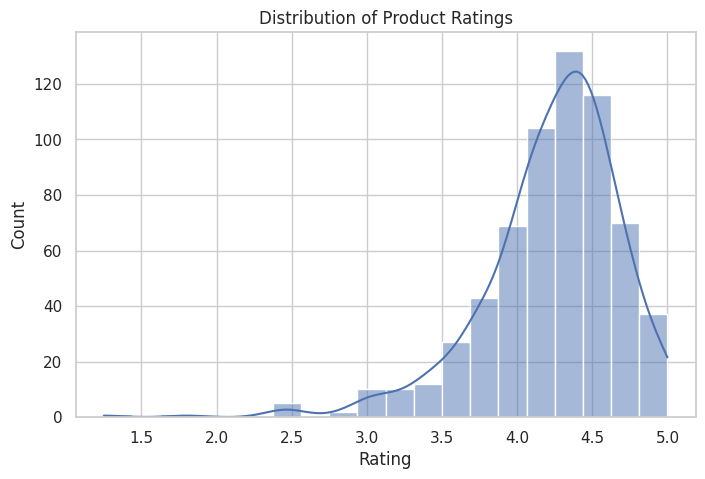

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(merged["rating"], bins=20, kde=True)
plt.title("Distribution of Product Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

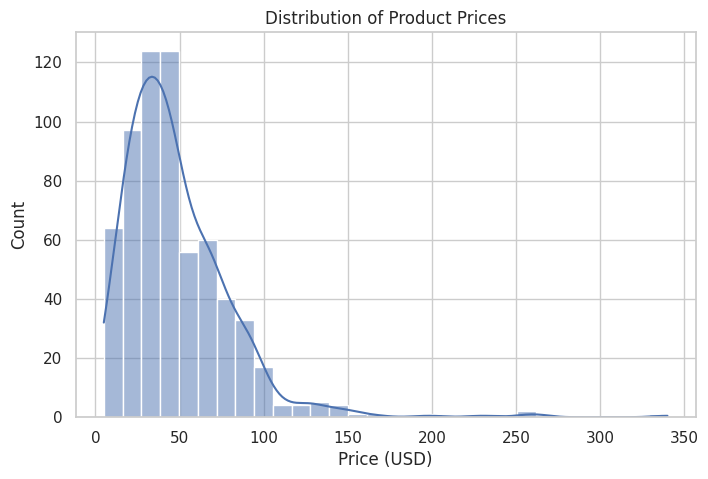

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(merged["price_usd"], bins=30, kde=True)
plt.title("Distribution of Product Prices")
plt.xlabel("Price (USD)")
plt.ylabel("Count")
plt.show()

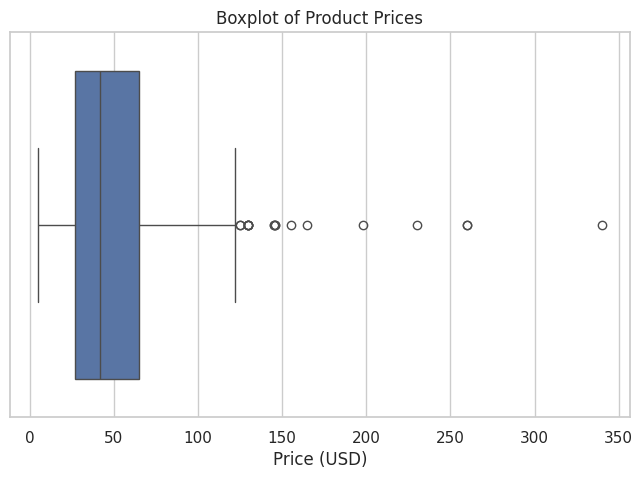

In [14]:
plt.figure(figsize=(8,5))
sns.boxplot(x=merged["price_usd"])
plt.title("Boxplot of Product Prices")
plt.xlabel("Price (USD)")
plt.show()

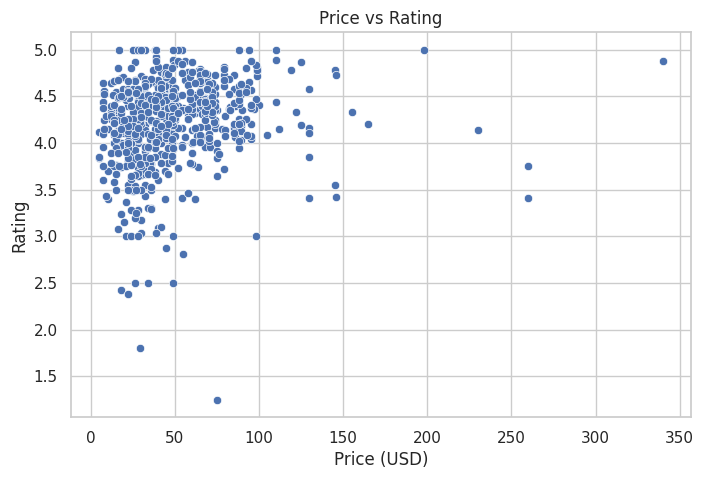

In [15]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=merged, x="price_usd", y="rating")
plt.title("Price vs Rating")
plt.xlabel("Price (USD)")
plt.ylabel("Rating")
plt.show()

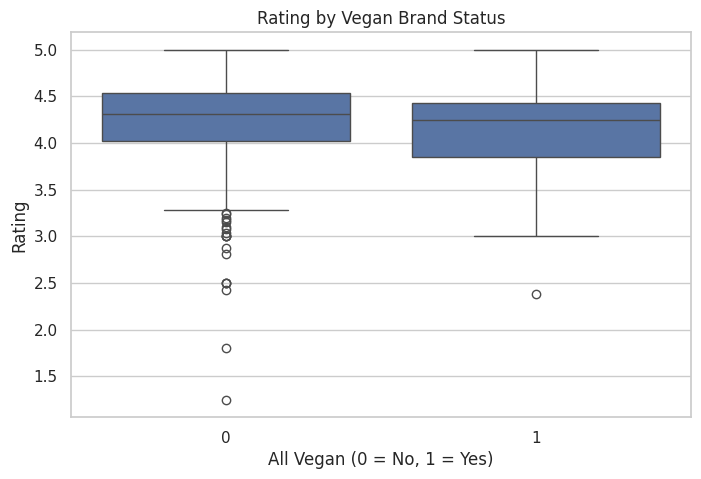

In [16]:
plt.figure(figsize=(8,5))
sns.boxplot(data=merged, x="All_vegan", y="rating")
plt.title("Rating by Vegan Brand Status")
plt.xlabel("All Vegan (0 = No, 1 = Yes)")
plt.ylabel("Rating")
plt.show()

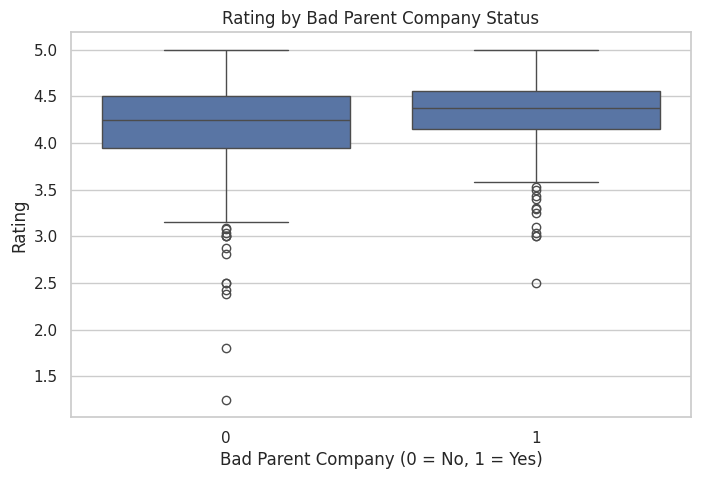

In [17]:
plt.figure(figsize=(8,5))
sns.boxplot(data=merged, x="Bad_parent_company", y="rating")
plt.title("Rating by Bad Parent Company Status")
plt.xlabel("Bad Parent Company (0 = No, 1 = Yes)")
plt.ylabel("Rating")
plt.show()

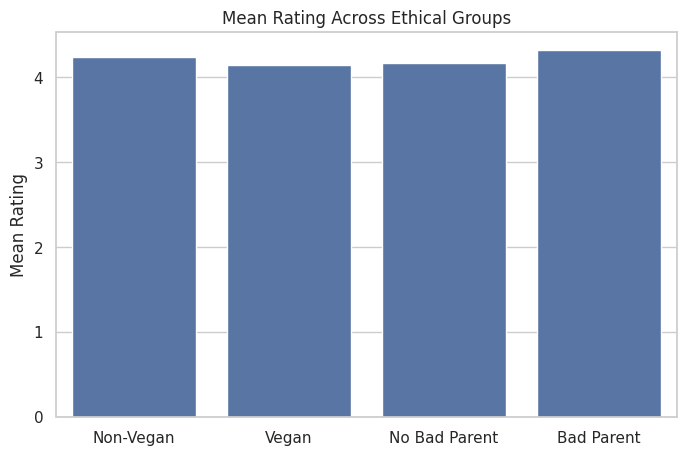

In [18]:
mean_ratings = pd.DataFrame({
    "Group": ["Non-Vegan", "Vegan", "No Bad Parent", "Bad Parent"],
    "Mean Rating": [
        merged[merged["All_vegan"] == 0]["rating"].mean(),
        merged[merged["All_vegan"] == 1]["rating"].mean(),
        merged[merged["Bad_parent_company"] == 0]["rating"].mean(),
        merged[merged["Bad_parent_company"] == 1]["rating"].mean()
    ]
})

plt.figure(figsize=(8,5))
sns.barplot(data=mean_ratings, x="Group", y="Mean Rating")
plt.title("Mean Rating Across Ethical Groups")
plt.ylabel("Mean Rating")
plt.xlabel("")
plt.show()

In [19]:
print("H0: There is no statistically significant relationship between price and rating.")
print("H1: There is a statistically significant relationship between price and rating.")

corr, p_value = spearmanr(merged["price_usd"], merged["rating"])

print("\nSpearman Correlation Results")
print("Correlation coefficient:", corr)
print("p-value:", p_value)

if p_value < 0.05:
    print("Result: Reject H0. Price and rating are significantly related.")
else:
    print("Result: Fail to reject H0. No significant relationship between price and rating.")

H0: There is no statistically significant relationship between price and rating.
H1: There is a statistically significant relationship between price and rating.

Spearman Correlation Results
Correlation coefficient: 0.24142080644667607
p-value: 6.310522778670712e-10
Result: Reject H0. Price and rating are significantly related.


In [20]:
print("H0: Ratings of vegan and non-vegan brands are not significantly different.")
print("H1: Ratings of vegan and non-vegan brands are significantly different.")

vegan_ratings = merged[merged["All_vegan"] == 1]["rating"]
nonvegan_ratings = merged[merged["All_vegan"] == 0]["rating"]

stat_vegan, p_vegan = mannwhitneyu(vegan_ratings, nonvegan_ratings, alternative="two-sided")

print("\nMann-Whitney U Test Results (Vegan vs Non-Vegan)")
print("Test statistic:", stat_vegan)
print("p-value:", p_vegan)

if p_vegan < 0.05:
    print("Result: Reject H0. Vegan status is associated with significantly different ratings.")
else:
    print("Result: Fail to reject H0. No significant difference between vegan and non-vegan ratings.")

H0: Ratings of vegan and non-vegan brands are not significantly different.
H1: Ratings of vegan and non-vegan brands are significantly different.

Mann-Whitney U Test Results (Vegan vs Non-Vegan)
Test statistic: 20328.5
p-value: 0.08016289728604294
Result: Fail to reject H0. No significant difference between vegan and non-vegan ratings.


In [21]:
print("H0: Ratings do not differ significantly by bad parent company status.")
print("H1: Ratings differ significantly by bad parent company status.")

bad_parent_ratings = merged[merged["Bad_parent_company"] == 1]["rating"]
good_parent_ratings = merged[merged["Bad_parent_company"] == 0]["rating"]

stat_parent, p_parent = mannwhitneyu(bad_parent_ratings, good_parent_ratings, alternative="two-sided")

print("\nMann-Whitney U Test Results (Bad Parent Company)")
print("Test statistic:", stat_parent)
print("p-value:", p_parent)

if p_parent < 0.05:
    print("Result: Reject H0. Parent company status is associated with significantly different ratings.")
else:
    print("Result: Fail to reject H0. No significant difference by parent company status.")

H0: Ratings do not differ significantly by bad parent company status.
H1: Ratings differ significantly by bad parent company status.

Mann-Whitney U Test Results (Bad Parent Company)
Test statistic: 58559.0
p-value: 2.6661406621905815e-05
Result: Reject H0. Parent company status is associated with significantly different ratings.


In [23]:
print("\n================ FINAL INTERPRETATION ================")

# Test 1
if p_value < 0.05:
    print("Test 1 (Price vs Rating): There is a statistically significant relationship between price and rating.")
else:
    print("Test 1 (Price vs Rating): There is no statistically significant relationship between price and rating.")

# Test 2
if p_vegan < 0.05:
    print("Test 2 (Vegan vs Non-Vegan): Ratings differ significantly between vegan and non-vegan brands.")
else:
    print("Test 2 (Vegan vs Non-Vegan): There is no significant difference in ratings between vegan and non-vegan brands.")

# Test 3
if p_parent < 0.05:
    print("Test 3 (Bad Parent Company): Ratings differ significantly depending on parent company status.")
else:
    print("Test 3 (Bad Parent Company): There is no significant difference in ratings based on parent company status.")

# Overall conclusion
print("\nOVERALL CONCLUSION:")

if (p_vegan < 0.05 or p_parent < 0.05) and p_value >= 0.05:
    print("Ethical factors appear to have a stronger effect on ratings than price. H1 is supported.")
elif p_value < 0.05 and (p_vegan >= 0.05 and p_parent >= 0.05):
    print("Price appears to have a stronger effect on ratings than ethical factors. H1 is not supported.")
elif p_value < 0.05 and (p_vegan < 0.05 or p_parent < 0.05):
    print("Both price and ethical factors influence ratings. Further analysis is needed to compare their strength.")
else:
    print("No strong evidence was found that either price or ethical factors significantly affect ratings. Fail to reject H0.")


================ FINAL INTERPRETATION ================
Test 1 (Price vs Rating): There is a statistically significant relationship between price and rating.
Test 2 (Vegan vs Non-Vegan): There is no significant difference in ratings between vegan and non-vegan brands.
Test 3 (Bad Parent Company): Ratings differ significantly depending on parent company status.

OVERALL CONCLUSION:
Both price and ethical factors influence ratings. Further analysis is needed to compare their strength.
